In [7]:
# Importing Libraries
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

 
# Loading data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda clean: ast.literal_eval(clean)if pd.notna(clean) else clean)

In [8]:
import seaborn as sns


In [9]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [12]:
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US['job_skills']

109        python
109             r
109       alteryx
109       tableau
180         excel
           ...   
784882        sql
784882        vba
784882    tableau
784882      excel
784882    alteryx
Name: job_skills, Length: 17440, dtype: object

In [13]:
df_DA_US[['salary_year_avg','job_skills']]

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


In [16]:
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])


In [18]:
df_DA_top_pay = df_DA_US_group.sort_values(by='median',ascending=False).head(10)
df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [21]:
df_DA_skills = df_DA_US_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False).head(10)
df_DA_skills
                                            

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


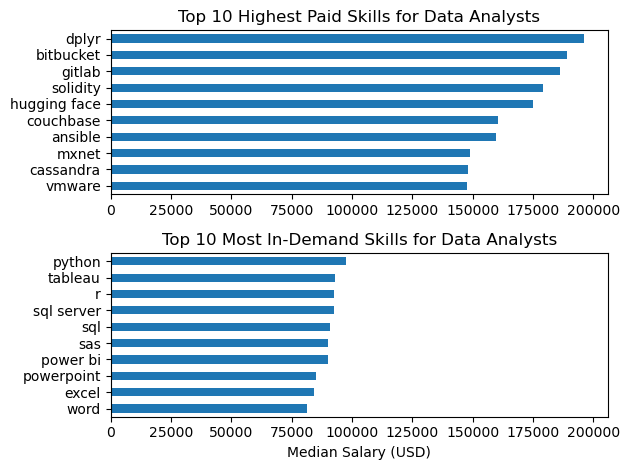

In [23]:
fig, ax = plt.subplots(2,1)
df_DA_top_pay[::-1].plot(kind='barh',y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')

df_DA_skills[::-1].plot(kind='barh',y='median', ax = ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()

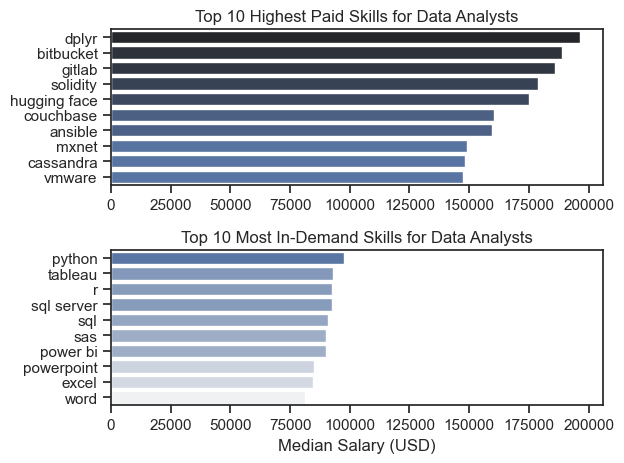

In [32]:
fig, ax = plt.subplots(2,1)
#df_DA_top_pay[::-1].plot(kind='barh',y='median', ax=ax[0], legend=False)
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r')
sns.set_theme(style='ticks')
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].legend_.remove()
ax[0].set_ylabel('')
ax[0].set_xlabel('')


#df_DA_skills[::-1].plot(kind='barh',y='median', ax = ax[1], legend=False)
sns.barplot(data = df_DA_skills,x = 'median', y=df_DA_skills.index,ax=ax[1],hue='median',palette='light:b')
sns.set_theme(style='ticks')
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].legend_.remove()
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()

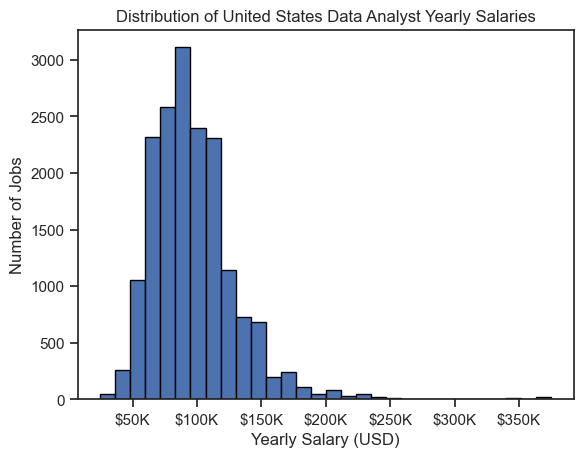

In [34]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

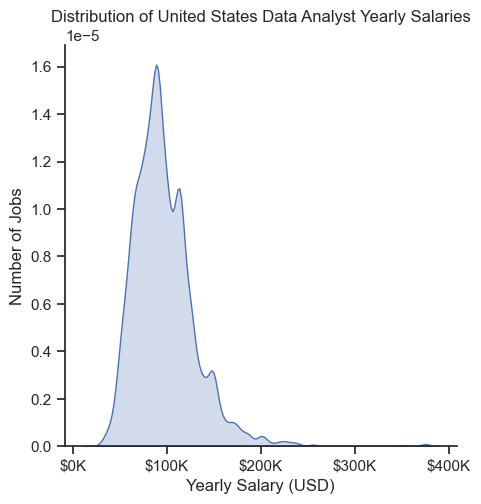

In [39]:
#df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

sns.set_theme(style='ticks')
sns.displot(df_DA_US['salary_year_avg'],kind='kde',fill=True)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

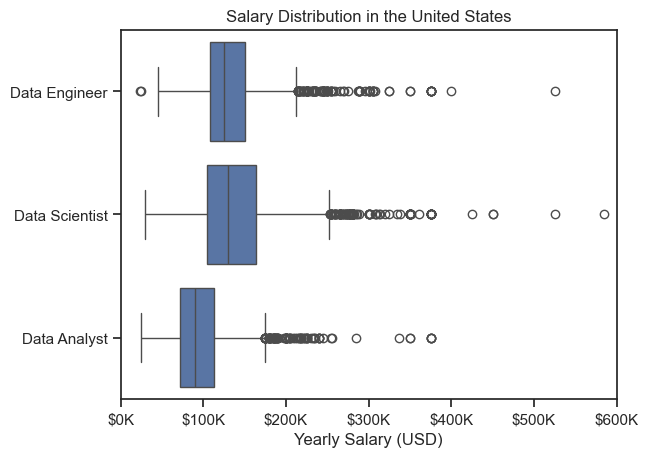

In [43]:
job_titles = ['Data Analyst','Data Engineer','Data Scientist']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']== 'United States')].dropna(subset=['salary_year_avg'])
job_list = [df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]

sns.boxplot(data=df_US, x='salary_year_avg',y='job_title_short')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.xlim(0,600000)
plt.ylabel('')
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()